# Threshold Sweep Analysis

This notebook performs threshold sweep analysis on pre-computed best_matches files.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, List
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

## Configuration

In [2]:
# Update these paths to match your setup
BASE_PATH = Path("../results/compare_outputs_sepsis40_greedy/matches")
OUTPUT_PATH = Path("../results/compare_outputs_sepsis40_greedy")

# Pilot names in desired order (for colors and legend)
PILOT_ORDER = ['DeepSeek-R1', 'GPT-5', 'L3.1  8B', 'L3.1 70B', 'L3.3 70B', 'Mixtral 8x7B']

# Color palette (matching R code)
COLORS = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00']  # Updated to match PILOT_ORDER
COLOR_MAP = {pilot: COLORS[i] for i, pilot in enumerate(PILOT_ORDER)}

# Threshold to highlight with larger point
BOLD_THRESHOLD = 0.1

# Thresholds to sweep
THRESHOLDS = [
    0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1,
    0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45, 0.5
]

## Load Data

In [3]:
# Dictionary mapping pilot names to their best_matches files
pilot_files = {
    pilot: BASE_PATH / pilot / 'best_matches2026-05-08.csv'
    for pilot in PILOT_ORDER
}

# Display file paths
print("Loading files:")
for pilot, path in pilot_files.items():
    exists = "✓" if path.exists() else "✗"
    print(f"  {exists} {pilot}: {path}")

Loading files:
  ✓ DeepSeek-R1: ../results/compare_outputs_sepsis40_greedy/matches/DeepSeek-R1/best_matches2026-05-08.csv
  ✓ GPT-5: ../results/compare_outputs_sepsis40_greedy/matches/GPT-5/best_matches2026-05-08.csv
  ✓ L3.1  8B: ../results/compare_outputs_sepsis40_greedy/matches/L3.1  8B/best_matches2026-05-08.csv
  ✓ L3.1 70B: ../results/compare_outputs_sepsis40_greedy/matches/L3.1 70B/best_matches2026-05-08.csv
  ✓ L3.3 70B: ../results/compare_outputs_sepsis40_greedy/matches/L3.3 70B/best_matches2026-05-08.csv
  ✓ Mixtral 8x7B: ../results/compare_outputs_sepsis40_greedy/matches/Mixtral 8x7B/best_matches2026-05-08.csv


In [4]:
def load_all_pilots(pilot_files: Dict[str, Path]) -> pd.DataFrame:
    """Load all best_matches files and combine them."""
    dfs = {}
    for pilot_name, filepath in pilot_files.items():
        df = pd.read_csv(filepath)
        df['pilot_name'] = pilot_name
        dfs[pilot_name] = df
    return dfs

# Load data
dfs = load_all_pilots(pilot_files)

df = dfs['GPT-5']

print(f"\nLoaded {len(df):,} total matches")
print(f"Pilots: {df['pilot_name'].nunique()}")
print(f"Cases: {df['common.bns'].nunique() if 'common.bns' in df.columns else 'N/A'}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
# df.head()
df


Loaded 3,269 total matches
Pilots: 1
Cases: 40

Columns: ['common.bns', 'files', 'pilot.files', 'v1', 'v2', 'error.rate', 'idx', 'match.idx', 'keep', 'ref.time', 'pilot.time', 'pilot_name']

First few rows:


,common.bns,files,pilot.files,v1,v2,error.rate,idx,match.idx,keep,ref.time,pilot.time,pilot_name
0,PMC10037274_body,/mnt/c/Research/textual-time-series-for-sepsis...,/mnt/c/Research/textual-time-series-for-sepsis...,Total bilirubin 129.4 μmol/L,total bilirubin 129.4 μmol/L,1.147971e-13,46,34.0,True,72,72,GPT-5
1,PMC10037274_body,/mnt/c/Research/textual-time-series-for-sepsis...,/mnt/c/Research/textual-time-series-for-sepsis...,Pain,pain,1.154632e-13,33,28.0,True,72,72,GPT-5
2,PMC10037274_body,/mnt/c/Research/textual-time-series-for-sepsis...,/mnt/c/Research/textual-time-series-for-sepsis...,Albumin 27.9 g/L,albumin 27.9 g/L,1.220135e-13,44,32.0,True,72,72,GPT-5
3,PMC10037274_body,/mnt/c/Research/textual-time-series-for-sepsis...,/mnt/c/Research/textual-time-series-for-sepsis...,Neutrophils 79.2%,neutrophils 79.2%,1.254552e-13,47,35.0,True,72,72,GPT-5
4,PMC10037274_body,/mnt/c/Research/textual-time-series-for-sepsis...,/mnt/c/Research/textual-time-series-for-sepsis...,Hypoproteinemia,hypoproteinemia,1.340039e-13,21,11.0,True,0,0,GPT-5
...,...,...,...,...,...,...,...,...,...,...,...,...
3264,PMC9647393_body,/mnt/c/Research/textual-time-series-for-sepsis...,/mnt/c/Research/textual-time-series-for-sepsis...,ICU admission,admitted to the intensive care unit,6.282078e-02,5,15.0,True,6,0,GPT-5
3265,PMC9647393_body,/mnt/c/Research/textual-time-series-for-sepsis...,/mnt/c/Research/textual-time-series-for-sepsis...,Electrocardiography showed frequent ventricula...,ventricular premature complex (VPC),6.489868e-02,27,19.0,True,360,1,GPT-5
3266,PMC9647393_body,/mnt/c/Research/textual-time-series-for-sepsis...,/mnt/c/Research/textual-time-series-for-sepsis...,Patient was brought to our emergency departmen...,brought to our emergency department,7.488871e-02,22,3.0,True,0,-3,GPT-5
3267,PMC9647393_body,/mnt/c/Research/textual-time-series-for-sepsis...,/mnt/c/Research/textual-time-series-for-sepsis...,Patient recovered and was discharged within on...,recovered,7.837320e-02,21,71.0,True,1008,1100,GPT-5


## Metric Calculation Functions

### Event Match Rate

In [5]:
from tts_metrics import calculate_match_rate

In [6]:
print("\nMatch Rates at Threshold 0.1:")

for pilot_, df in dfs.items():
    result = calculate_match_rate(df, threshold=0.1)
    print(f"Pilot: {pilot_}, Match Rate: {result['match_rate'].iloc[0]:.2f}")


Match Rates at Threshold 0.1:
Pilot: DeepSeek-R1, Match Rate: 0.79
Pilot: GPT-5, Match Rate: 0.91
Pilot: L3.1  8B, Match Rate: 0.53
Pilot: L3.1 70B, Match Rate: 0.66
Pilot: L3.3 70B, Match Rate: 0.76
Pilot: Mixtral 8x7B, Match Rate: 0.68


### Concordance

In [7]:
from tts_metrics import calculate_concordance

In [8]:
rows = []

for pilot_, df in dfs.items():
    concordance = calculate_concordance(df, threshold=0.1)
    
    quantiles_cindex = pd.DataFrame({
        'pilot': [pilot_],
        'concordance': [concordance['cindex'].median()],
        'mean': [concordance['cindex'].mean()],
        'c25': [concordance['cindex'].quantile(0.25)],
        'c75': [concordance['cindex'].quantile(0.75)]
    })
    
    rows.append(quantiles_cindex)

concordance_df = pd.concat(rows, ignore_index=True)
concordance_df

,pilot,concordance,mean,c25,c75
0,DeepSeek-R1,0.888601,0.848066,0.796249,0.933682
1,GPT-5,0.964600,0.949845,0.945165,0.979976
2,L3.1 8B,0.855521,0.807884,0.775759,0.925021
3,L3.1 70B,0.918883,0.875561,0.869859,0.952210
4,L3.3 70B,0.907703,0.866393,0.862667,0.962182
5,Mixtral 8x7B,0.905843,0.849099,0.774448,0.943548


### AULTC

In [9]:
from tts_metrics import calculate_aultc

In [10]:
rows = []

for pilot_, df in dfs.items():
    aultc = calculate_aultc(
        df, 
        threshold=0.1, 
        upper_limit=np.log(60*24*365.26)
    )
    
    rows.append({
        'pilot': pilot_,
        'aultc': aultc
    })

aultc_df = pd.DataFrame(rows)
aultc_df

,pilot,aultc
0,DeepSeek-R1,0.776796
1,GPT-5,0.821511
2,L3.1 8B,0.685380
3,L3.1 70B,0.719196
4,L3.3 70B,0.741625
5,Mixtral 8x7B,0.715026


## Run Threshold Sweep

In [11]:
results = {}
THRESHOLDS = [
    0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1,
    0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45, 0.5
]

from tts_metrics import calculate_match_rate, calculate_concordance, calculate_aultc_simple

THRESHOLDS = np.arange(0.01, 0.51, 0.01).round(2)

for pilot_, df in dfs.items():
    results[pilot_] = {"thresholds": [], "event_match_rate": [], 'concordance': [], "aultc": []}
    for thresholds in THRESHOLDS:
        # Event match rate
        emr_result = calculate_match_rate(df, threshold=thresholds)
        match_rate = emr_result['match_rate'].iloc[0]
        
        # Concordance
        conc_result = calculate_concordance(
            df, 
            threshold=thresholds,
            # use_original_files=True
        )
        concordance = conc_result['cindex'].median()

        # AULTC
        aultc_result = calculate_aultc_simple(
            df,
            threshold=thresholds,
            upper_limit=np.log(60*24*365.26)
        )
        aultc = aultc_result

        # Store results
        results[pilot_]["thresholds"].append(thresholds)
        results[pilot_]["event_match_rate"].append(match_rate)
        results[pilot_]["concordance"].append(concordance)
        results[pilot_]["aultc"].append(aultc)

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Model name and color mapping
model_name_mapping = {
    'DeepSeek-R1': 'DeepSeek-R1',
    'GPT-5': 'GPT-5',
    'L3.1  8B': 'L3.1  8B',
    'L3.1 70B': 'L3.1 70B',
    'L3.3 70B': 'L3.3 70B',
    'Mixtral 8x7B': 'Mixtral 8x7B'
}

color_mapping = {
    'DeepSeek-R1': '#E69F00',
    'GPT-5': '#56B4E9',
    'L3.1  8B': '#009E73',
    'L3.1 70B': '#F0E442',
    'L3.3 70B': '#0072B2',
    'Mixtral 8x7B': '#D55E00'
}


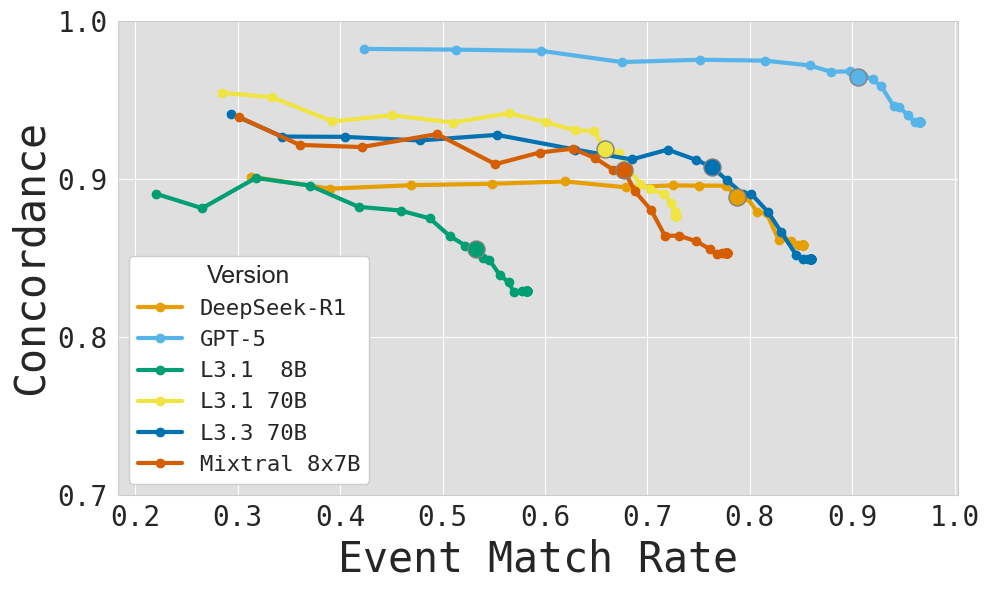

In [13]:
# Create Concordance vs Event Match Rate figure
plt.figure(figsize=(10, 6))

for pilot, data in results.items():
    thresholds = np.array(data['thresholds'])
    event_match_rate = np.array(data['event_match_rate'])
    concordance = np.array(data['concordance'])
    
    # Get the proper model name and color from the mapping
    model_name = model_name_mapping.get(pilot, pilot)
    color = color_mapping.get(pilot, '#000000')  # Default to black if no color found

    # Highlight threshold = 0.1
    highlight_idx = thresholds == 0.1
    highlight_x = event_match_rate[highlight_idx]
    highlight_y = concordance[highlight_idx]

    # Plot Concordance vs Event Match Rate
    plt.plot(event_match_rate, concordance, label=model_name, marker='o', markersize=6, linestyle='-', linewidth=3, color=color)
    
    # Highlight with same color as the line, but with a black border
    plt.scatter(highlight_x, highlight_y, color=color, s=150, zorder=5, edgecolor='gray', linewidth=1) 

# Set y-axis ticks to 0.7, 0.8, 0.9, 1.0
plt.yticks(np.arange(0.7, 1.1, 0.1), fontsize=20, family='monospace')

plt.xlabel('Event Match Rate', fontsize=30, family='monospace')
plt.ylabel('Concordance', fontsize=30, family='monospace')

# Customize grid and background
plt.grid('major', color='white')
plt.gca().set_facecolor('#DFDFDF')

plt.xticks(fontsize=20, family='monospace')
plt.yticks(fontsize=20, family='monospace')

# Modify the legend to have a solid background
plt.legend(title='Version', title_fontsize=18, loc='lower left', prop={'family': 'monospace', 'size': 16}, 
           frameon=True, facecolor='white', framealpha=1)

# Tight layout for better spacing
plt.tight_layout()

# Limit y-axis to [0.7, 1.0]
plt.ylim(0.7, 1)

plt.savefig(OUTPUT_PATH / 'concordance_vs_event_match_rate.pdf', bbox_inches='tight', dpi=300)

# Show plot
plt.show()


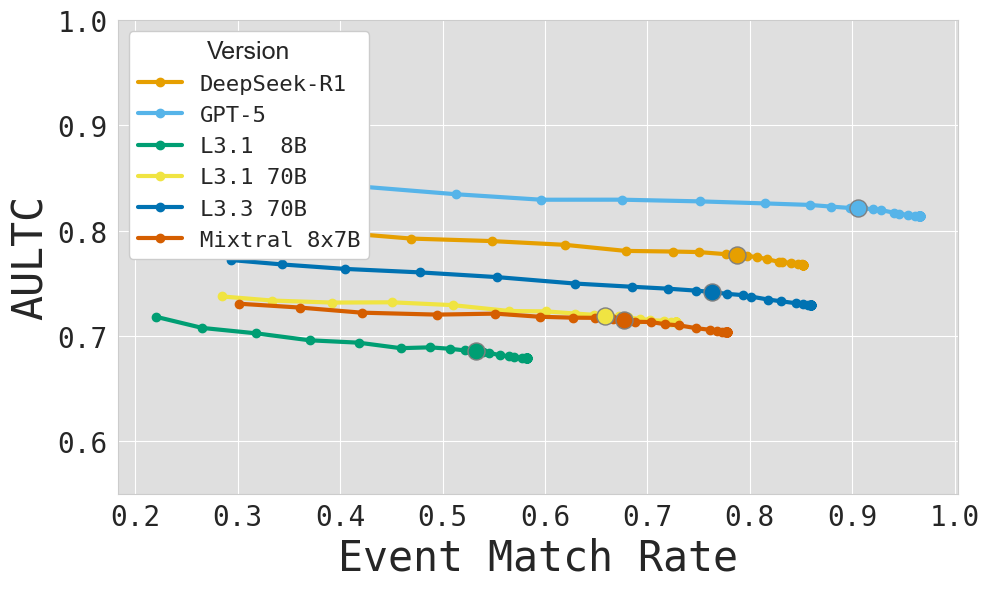

In [14]:
# Create AULTC vs Event Match Rate figure
plt.figure(figsize=(10, 6))

for pilot, data in results.items():
    thresholds = np.array(data['thresholds'])
    event_match_rate = np.array(data['event_match_rate'])
    aultc = np.array(data['aultc'])
    
    # Get the proper model name and color from the mapping
    model_name = model_name_mapping.get(pilot, pilot)
    color = color_mapping.get(pilot, '#000000')  # Default to black if no color found

    # Highlight threshold = 0.1
    highlight_idx = thresholds == 0.1
    highlight_x = event_match_rate[highlight_idx]
    highlight_y = aultc[highlight_idx]

    # Plot AULTC vs Event Match Rate
    plt.plot(event_match_rate, aultc, label=model_name, marker='o', markersize=6, linestyle='-', linewidth=3, color=color)
    
    # Highlight with same color as the line, but with a black border
    plt.scatter(highlight_x, highlight_y, color=color, s=150, zorder=5, edgecolor='gray', linewidth=1)  # Highlight with border

# Set y-axis ticks to 0.7, 0.8, 0.9, 1.0
plt.yticks(np.arange(0.6, 1.1, 0.1), fontsize=20, family='monospace')

plt.xlabel('Event Match Rate', fontsize=30, family='monospace')
plt.ylabel('AULTC', fontsize=30, family='monospace')

# Customize grid and background
plt.grid('major', color='white')
plt.gca().set_facecolor('#DFDFDF')

plt.xticks(fontsize=20, family='monospace')
plt.yticks(fontsize=20, family='monospace')

# Modify the legend to have a solid background
plt.legend(title='Version', title_fontsize=18, loc='upper left', prop={'family': 'monospace', 'size': 16}, 
           frameon=True, facecolor='white', framealpha=1)

# Tight layout for better spacing
plt.tight_layout()

# Limit y-axis to [0.7, 1.0]
plt.ylim(0.55, 1)

plt.savefig(OUTPUT_PATH / 'aultc_vs_event_match_rate.pdf', bbox_inches='tight', dpi=300)

# Show plot
plt.show()